In [343]:
import sys
import os

# Add parent directory to path to import from app
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, timezone
from app.repositories.price_data import fetch_bulk_price_data_for_tickers


In [344]:
tickers = ['SPY', 'QQQ', 'GLD', 'AAL', 'TSLA', 'NVDA', 'AMD', 'KR', 'BTC', 'ETH', 'IGSB', 'UTEN', 'COST', 'PLTR']

start = '2020-10-15'
end = '2025-10-15'

data = fetch_bulk_price_data_for_tickers(tickers, start, end, 'daily')

In [345]:
df = pd.DataFrame.from_dict(data)
print(df.tail(5))


              BTC   UTEN     GLD    AAL     AMD    TSLA     SPY   IGSB     KR  \
date                                                                            
2025-10-08  54.65  44.17  372.25  11.80  235.51  438.65  673.00  52.91  68.13   
2025-10-09  53.59  44.13  365.47  11.61  233.00  435.56  671.19  52.88  67.55   
2025-10-10  51.61  44.47  369.24  11.52  214.77  413.27  653.12  52.93  67.79   
2025-10-13  51.32  44.47  378.09  11.74  216.41  435.89  663.05  53.01  67.13   
2025-10-14  49.90  44.59  381.09  12.19  217.99  429.21  662.21  53.04  69.13   

               QQQ    NVDA    PLTR    COST  
date                                        
2025-10-08  611.50  189.10  183.55  914.80  
2025-10-09  610.72  192.53  185.48  942.89  
2025-10-10  589.48  183.14  175.41  930.23  
2025-10-13  602.04  188.31  177.19  935.40  
2025-10-14  598.08  180.02  179.74  946.60  


In [346]:
data = pd.DataFrame(data['PLTR'])
data.rename(columns={'close':'price'}, inplace=True)
print(data.tail(5))
data.info()


             price
date              
2025-10-08  183.55
2025-10-09  185.48
2025-10-10  175.41
2025-10-13  177.19
2025-10-14  179.74
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1216 entries, 2020-10-15 to 2025-10-14
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   1216 non-null   float64
dtypes: float64(1)
memory usage: 51.3 KB


In [347]:
data['SMA1'] = data['price'].rolling(window=55).mean()
data['SMA2'] = data['price'].rolling(window=365).mean()


data.tail(5)


,price,SMA1,SMA2
date,,,
2025-10-08,183.55,151.905636,69.346384
2025-10-09,185.48,153.035091,69.785918
2025-10-10,175.41,153.973818,70.198192
2025-10-13,177.19,154.971636,70.617781
2025-10-14,179.74,155.842909,71.044959


<Axes: xlabel='date'>

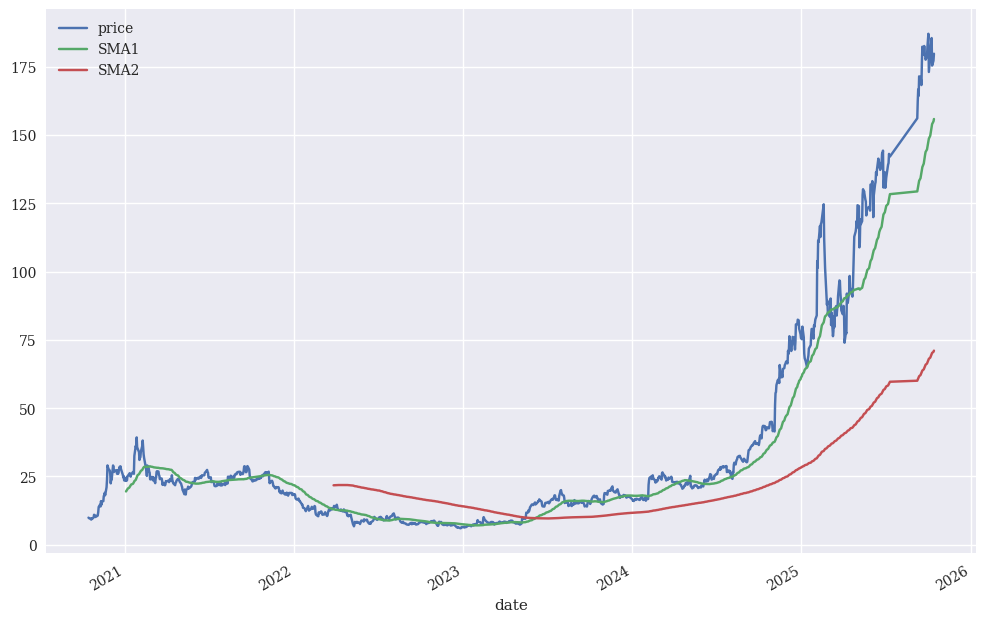

In [348]:
%matplotlib inline
from pylab import mpl, plt 

plt.style.use('seaborn-v0_8') 
mpl.rcParams['font.family'] = 'serif'
data.plot(figsize=(12, 8))


In [349]:
data['position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1) #Generate trading signals
data.dropna(inplace=True)

In [350]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))
data['strategy'] = data['position'].shift(1) * data['returns']

In [351]:
data[['returns', 'strategy']].sum()
data[['returns', 'strategy']].sum().apply(np.exp)

returns     13.403430
strategy    11.154211
dtype: float64

<Axes: xlabel='date'>

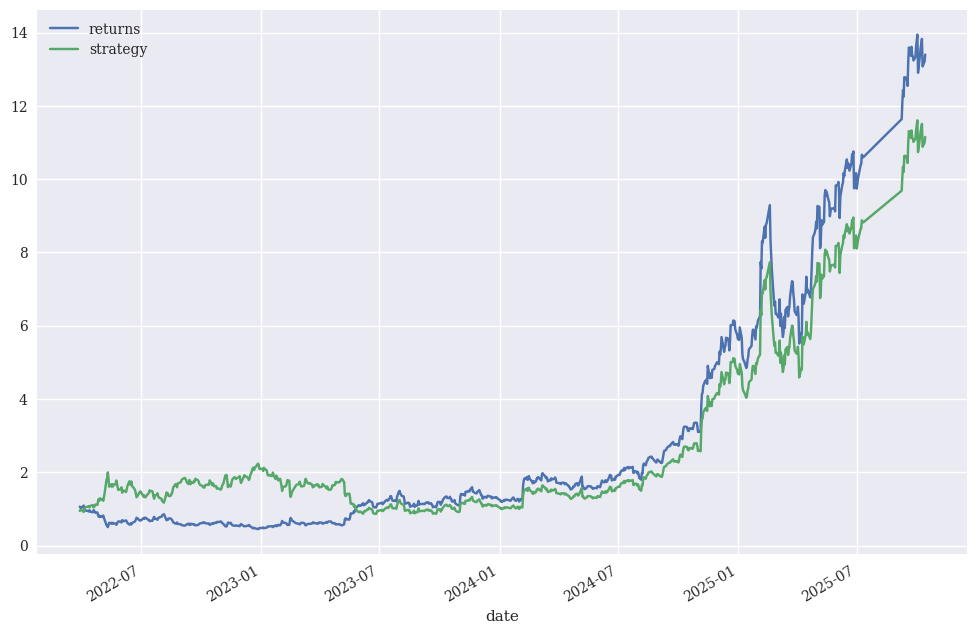

In [352]:
data[['returns', 'strategy']].cumsum().apply(np.exp).plot(figsize=(12, 8))

In [353]:
annualized_ret = np.exp(data[['returns', 'strategy']].mean()*365)-1
annualized_vol = (data[['returns', 'strategy']].apply(np.exp)-1).std()*365**0.5
print(annualized_ret)
print(annualized_vol)

returns     2.044185
strategy    1.813546
dtype: float64
returns     0.842532
strategy    0.840869
dtype: float64


<Axes: xlabel='date'>

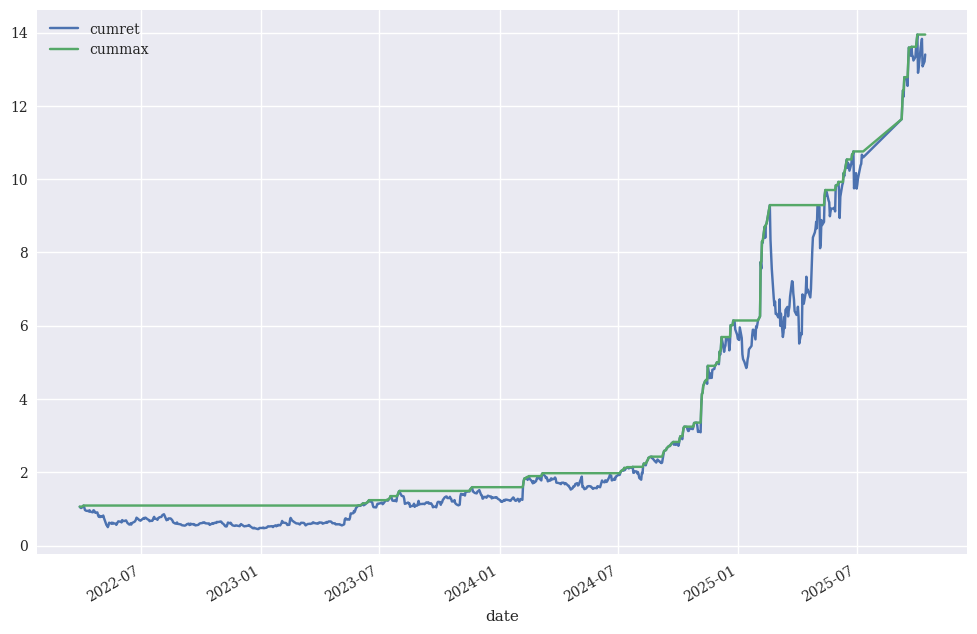

In [354]:
data['cumret'] = data['returns'].cumsum().apply(np.exp)
data['cummax'] = data['cumret'].cummax()
data[['cumret', 'cummax']].plot(figsize=(12, 8))

In [355]:
drawdown = data['cummax'] - data['cumret']
# The difference between the cumulative max and the cumulative return is the drawdown 
drawdown.max()

np.float64(3.7792692020879946)

In [356]:
temp = drawdown[drawdown == 0]
periods = (temp.index[1:].to_pydatetime() - temp.index[:-1].to_pydatetime())

In [357]:
periods[12:15]

array([datetime.timedelta(days=108), datetime.timedelta(days=3),
       datetime.timedelta(days=78)], dtype=object)

In [358]:
periods.max()

datetime.timedelta(days=421)